# Steam Sales Dataset Analysis (Deep Learning Models)

This section focuses on deep learning approaches to model and predict game pricing based on textual and structured features from the Steam dataset. While baseline models provide interpretable and efficient benchmarks, deep learning methods are capable of capturing more complex, non-linear relationships within high-dimensional data.

In this phase, neural network-based architectures are used to improve representation learning from game descriptions and metadata. Instead of relying solely on handcrafted feature interactions, deep learning models automatically learn hierarchical patterns from input data, making them particularly effective for large-scale and unstructured datasets.

## Import Libraries

In [1]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from litellm import completion
import numpy as np
from tqdm.notebook import tqdm
import csv
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR

from sales_util.evaluator import evaluate
from sales_util.items_data import Item

In [2]:
# Load env file
load_dotenv(override=True)

True

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Load Dataset From HuggingFace

In [4]:
username = "KumudithaSilva"
dataset = f"{username}/items_llm_raw_lite"

train, val, test = Item.from_hub(dataset)

items = train + val + test

print(f"Loaded {len(items):,} items")

Loaded 22,000 items


## Feature Extraction

In [5]:
def get_item_features(item):
    return {
        "peakCCU": item.peakCCU,
        "required_age": item.required_age,
        "dlc": item.dlcCount,
        "supportWindows": int(item.supportWindows),
        "supportMac": int(item.supportMac),
        "supportLinux": int(item.supportLinux),
        "positive": item.positive,
        "negative": item.negative,
        "achievements": item.achievements,
        "recommendation": item.recommendations or 0,
        "release_year": item.release_year or 0,
        "release_month": item.release_month or 0,
        "release_day": item.release_day or 0,
        "min_estimatedOwners": item.min_estimatedOwners or 0,
        "max_estimatedOwners": item.max_estimatedOwners or 0,
        "supported_languages": item.supported_languages or 0,
        "num_developers": item.num_developers or 0,
        "num_publishers": item.num_publishers or 0,
        "num_categories": item.num_categories or 0,
        "num_genres": item.num_genres or 0,
    }

In [6]:
X = np.array([list(get_item_features(item).values())for item in train])
y = np.array([item.price for item in train])

## Train and Test

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Standardization

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Create Tensors

In [9]:
X_train_tensor = torch.FloatTensor(X_train).to(device)
X_test_tensor  = torch.FloatTensor(X_test).to(device)

y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1).to(device)
y_test_tensor  = torch.FloatTensor(y_test).unsqueeze(1).to(device)

## Neural Network

In [10]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(NeuralNetwork, self).__init__()
        self.layer1 = nn.Linear(input_size, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 64)
        self.layer4 = nn.Linear(64, 64)
        self.layer5 = nn.Linear(64, 64)
        self.layer6 = nn.Linear(64, 64)
        self.layer7 = nn.Linear(64, 64)
        self.layer8 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        output1 = self.relu(self.layer1(x))
        output2 = self.relu(self.layer2(output1))
        output3 = self.relu(self.layer3(output2))
        output4 = self.relu(self.layer4(output3))
        output5 = self.relu(self.layer5(output4))
        output6 = self.relu(self.layer6(output5))
        output7 = self.relu(self.layer7(output6))
        output8 = self.layer8(output7)
        return output8

In [11]:
# Create the Train loader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [12]:
input_size = X_train_tensor.shape[1]
model = NeuralNetwork(input_size)

In [13]:
for p in model.parameters():
    print(f"{p.shape}: {p.numel()} parameters")

torch.Size([128, 20]): 2560 parameters
torch.Size([128]): 128 parameters
torch.Size([64, 128]): 8192 parameters
torch.Size([64]): 64 parameters
torch.Size([64, 64]): 4096 parameters
torch.Size([64]): 64 parameters
torch.Size([64, 64]): 4096 parameters
torch.Size([64]): 64 parameters
torch.Size([64, 64]): 4096 parameters
torch.Size([64]): 64 parameters
torch.Size([64, 64]): 4096 parameters
torch.Size([64]): 64 parameters
torch.Size([64, 64]): 4096 parameters
torch.Size([64]): 64 parameters
torch.Size([1, 64]): 64 parameters
torch.Size([1]): 1 parameters


In [14]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Number of trainable parameters: {trainable_params:,}")

Number of trainable parameters: 31,809


In [15]:
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = model.to(device) 

EPOCHS = 25

train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_train_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = loss_fn(outputs, batch_y)

        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_tensor)
        val_loss = loss_fn(val_outputs, y_test_tensor)
    test_losses.append(val_loss.item())

    # print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {avg_train_loss:.4f}, Test Loss: {val_loss.item():.4f}")

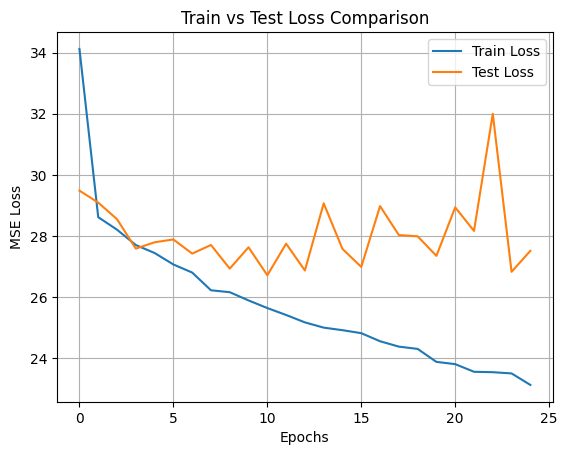

In [16]:
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Train vs Test Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
def neural_network(items):
    model.eval()
    with torch.no_grad():
        X_val = np.array([list(get_item_features(items).values())])
        X_val_scale = scaler.transform(X_val)

        X_val_tensor = torch.FloatTensor(X_val_scale).to(device)

        result = model(X_val_tensor)[0].item()
    return max(0, result)

In [18]:
evaluate(neural_network, test)

  0%|          | 0/200 [00:00<?, ?it/s]

$8 $4 $3 $3 $2 $2 $7 $0 $1 $3 $18 $4 $2 $2 $7 $3 $3 $12 $2 $3 $11 $2 $3 $4 $4 $1 $1 $2 $2 $2 $5 $3 $2 $9 $3 $6 $2 $3 $3 $0 $1 $4 $1 $3 $5 $6 $0 $0 $2 $4 $4 $0 $4 $2 $5 $1 $1 $61 $4 $5 $4 $3 $4 $15 $3 $4 $1 $0 $3 $1 $3 $2 $0 $1 $1 $3 $3 $5 $2 $1 $6 $3 $5 $3 $2 $3 $8 $3 $2 $1 $2 $9 $3 $1 $8 $1 $2 $2 $3 $0 $3 $5 $1 $5 $1 $1 $6 $6 $5 $0 $2 $10 $1 $2 $8 $4 $0 $4 $3 $1 $0 $4 $1 $6 $4 $0 $4 $3 $11 $5 $26 $2 $0 $1 $1 $15 $0 $2 $6 $3 $7 $3 $4 $0 $5 $1 $1 $5 $2 $15 $2 $5 $1 $2 $1 $5 $2 $1 $2 $4 $3 $4 $5 $5 $2 $3 $2 $4 $2 $25 $39 $9 $3 $5 $0 $1 $6 $6 $2 $7 $8 $1 $16 $0 $3 $7 $1 $4 $0 $10 $3 $1 $5 $3 $4 $1 $1 $8 $1 $4 